In [1]:
import os
import sys
import json
import time
import glob

NOTEBOOK_DIR = os.getcwd()
VOICELK_ML = os.path.dirname(NOTEBOOK_DIR)          # .../voicelk_ml
TTS_ROOT = os.path.dirname(VOICELK_ML)               # .../TTS (project root)
MODELS_DIR = os.path.join(TTS_ROOT, "Models")
DATA_DIR = os.path.join(VOICELK_ML, "data")
METADATA_PATH = os.path.join(DATA_DIR, "pathnirwana_metadata.txt")
OUT_DIR = os.path.join(NOTEBOOK_DIR, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# Vendored source (NOT pip-installed) — see model_training/requirements.txt
sys.path.insert(0, os.path.join(VOICELK_ML, "model_training"))
sys.path.insert(0, os.path.join(VOICELK_ML, "model_engine"))

RUN_A = os.path.join(MODELS_DIR, "voicelk_vits_pathnirwana-September-02-2026_10+41AM-722d5af")
RUN_B = os.path.join(MODELS_DIR, "voicelk_vits_pathnirwana-September-03-2026_06+35PM-de782c1")

RUN_A_CKPT = os.path.join(RUN_A, "best_model_51660.pth")
RUN_B_CKPT = os.path.join(RUN_B, "best_model_820.pth")
RUN_A_CONFIG = os.path.join(RUN_A, "config.json")
RUN_B_CONFIG = os.path.join(RUN_B, "config.json")
RUN_A_EVENTS = glob.glob(os.path.join(RUN_A, "events.out.tfevents.*"))
RUN_A_EVENTS = RUN_A_EVENTS[0] if RUN_A_EVENTS else None

print("MODELS_DIR :", MODELS_DIR, os.path.isdir(MODELS_DIR))
print("RUN_A ckpt :", RUN_A_CKPT, os.path.isfile(RUN_A_CKPT))
print("RUN_B ckpt :", RUN_B_CKPT, os.path.isfile(RUN_B_CKPT))
print("RUN_A events:", RUN_A_EVENTS)
print("METADATA   :", METADATA_PATH, os.path.isfile(METADATA_PATH))

MODELS_DIR : d:\RUSL\Final Project\TTS\Models True
RUN_A ckpt : d:\RUSL\Final Project\TTS\Models\voicelk_vits_pathnirwana-September-02-2026_10+41AM-722d5af\best_model_51660.pth True
RUN_B ckpt : d:\RUSL\Final Project\TTS\Models\voicelk_vits_pathnirwana-September-03-2026_06+35PM-de782c1\best_model_820.pth True
RUN_A events: d:\RUSL\Final Project\TTS\Models\voicelk_vits_pathnirwana-September-02-2026_10+41AM-722d5af\events.out.tfevents.1788345665.9ed6bee8d812.9753.0
METADATA   : d:\RUSL\Final Project\TTS\voicelk_ml\data\pathnirwana_metadata.txt True


## 0. Headline finding — Data integrity bug (`num_speakers=234` සත්‍ය නෙවෙයි)

Evaluation එක පටන් ගන්න කලින්, dataset එකේ තිබුණු real issue එකක් මෙතන flag කරනවා — මොකද මේක Fairness, Generalization, සහ Performance metrics තුනටම effect කරනවා.

`model_training/formatters.py` හි `pathnirwana_formatter()` එක metadata line එකක් `line.split("|")` කරලා `cols[0]`=wav, `cols[1]`=text, `cols[2]`=speaker_id විදිහට කෙලින්ම index කරනවා. ඒත් IPA phoneme text එකේ ඇතුළතම (nasal/geminate sequences වලට) literal `|` character පාවිච්චි වෙනවා (උදා: `n|ə|m`, `ɡ|u|ɳ|a`). එහෙම පේළියක් `split("|")` කළාම fields 3ට වඩා වැඩි ගණනක් හැදෙනවා — ඒ නිසා `cols[1]` කියන්නේ sentence එකේ පළමු embedded-pipe එකට කලින් තියෙන කොටස විතරයි (ඉතුරු text එක silent ලෙස කැපිලා යනවා), සහ `cols[2]` කියන්නේ ඇත්තටම phoneme text එකේම කොටසක් — real speaker id එක නෙවෙයි.

පහළ cell එකෙන් මේක exact ලෙස verify කරනවා (pure Python, model load කරන්නේ නෑ — ඉක්මනින් run කරන්න පුළුවන්).

In [2]:
def parse_with_current_buggy_formatter(path):
    """Exactly mirrors model_training/formatters.py::pathnirwana_formatter's parsing logic."""
    items, speakers, malformed = [], set(), 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cols = line.split("|")
            if len(cols) < 3:
                continue
            if len(cols) != 3:
                malformed += 1
            text = cols[1]
            speaker_name = cols[2]
            speakers.add(speaker_name)
            items.append({"audio_file": cols[0], "text": text, "speaker_name": speaker_name})
    return items, speakers, malformed

items, speakers, malformed = parse_with_current_buggy_formatter(METADATA_PATH)
print(f"Total lines parsed          : {len(items)}")
print(f"Lines with embedded '|' bug : {malformed}  ({malformed/len(items):.1%} of the dataset)")
print(f"Unique 'speaker_name' values produced by the buggy formatter: {len(speakers)}")
print("Sample of bogus (non-numeric) speaker_name values:")
for s in sorted(speakers):
    if not s.strip().isdigit():
        print("   ", repr(s)[:80])
        if list(speakers).index(s) > 15:
            break

# Ground truth: what is the *real* last-field speaker id, ignoring the bug?
real_speakers = set()
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        wav, rest = line.split("|", 1)
        _, real_speaker = rest.rsplit("|", 1)
        real_speakers.add(real_speaker)
print("\nReal unique speakers (last '|'-delimited field, robust to embedded pipes):", real_speakers)

Total lines parsed          : 3300
Lines with embedded '|' bug : 1021  (30.9% of the dataset)
Unique 'speaker_name' values produced by the buggy formatter: 234
Sample of bogus (non-numeric) speaker_name values:
    'a'

Real unique speakers (last '|'-delimited field, robust to embedded pipes): {'01'}


**අපේක්ෂිත output එක:** `malformed` ≈ 1021 (dataset එකෙන් 31%ක්), bogus `speakers` ගණන **234**ක් (config.json හි `num_speakers: 234` එකට හරියටම ගැලපෙනවා — ඒක coincidence එකක් නෙවෙයි), සහ `real_speakers` = `{'01'}` විතරයි.

**මේකෙන් implication:**
1. Model එක train වෙලා තියෙන්නේ **single-speaker dataset එකක්** හැටියටයි, ඒත් config එක 234-speaker embedding table එකක් හදලා තියෙනවා. ඉන් 233ක්ම corrupted/mislabeled fragments වලින් train වෙච්ච bogus embeddings — inference වෙලාවේ `speaker_id=1..233` පාවිච්චි කළොත් predictable නොවන / degraded output එකක් එනවා විය හැක.
2. Dataset එකෙන් 31%ක (1021 sentences) training text එක silently truncate වෙලා — sentence එකේ දිග කොටස model එකට කවදාවත් train වෙලා නෑ, ඒ නිසා දිග/complex phoneme sequences වලට model එකේ generalization එක අඩුවෙන්න පුළුවන්.
3. **Fix එක:** `formatters.py` හි `pathnirwana_formatter` (සහ `openslr_formatter`) වල `cols = line.split("|")` වෙනුවට, පහත විදිහට wav/speaker දෙපැත්තෙන්ම fix කරලා middle එක text විදිහට ගන්නවා:
```python
wav_file, rest = line.split("|", 1)
text, speaker_name = rest.rsplit("|", 1)
```
එතකොට embedded `|` කීයක් තිබුණත් text එකට ම ඒවා preserve වෙනවා, speaker_id එකත් හරි.

In [3]:
def parse_with_fixed_formatter(path):
    items, speakers = [], set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            wav_file, rest = line.split("|", 1)
            text, speaker_name = rest.rsplit("|", 1)
            speakers.add(speaker_name)
            items.append({"audio_file": wav_file, "text": text, "speaker_name": speaker_name})
    return items, speakers

fixed_items, fixed_speakers = parse_with_fixed_formatter(METADATA_PATH)
print("Fixed parser -> unique speakers:", fixed_speakers)
print("Fixed parser -> total items    :", len(fixed_items))
print("Longest recovered text (previously truncated) sample:")
longest = max(fixed_items, key=lambda x: len(x["text"]))
print(" ", longest["audio_file"], "->", longest["text"][:120], "...")

Fixed parser -> unique speakers: {'01'}
Fixed parser -> total items    : 3300
Longest recovered text (previously truncated) sample:
  wavs/sin_01_00119.wav -> sad̪d̪haːʋaja , sat̪ijaja , hirijaja , ot̪t̪appajaja , aloːbhajaja , ad̪oːsajaja , t̪at̪ramadʒdʒhat̪t̪at̪aːʋaja , kaːjap ...


---
## 1. Performance Metrics

### 1.1 Applicability mapping

| Checklist metric | මේ VITS model එකට apply වෙනවද | හේතුව / විකල්පය |
|---|---|---|
| Accuracy / Precision / Recall / F1 | ❌ නෑ | Classification task එකක් නෙවෙයි |
| ROC-AUC / PR-AUC / Confusion Matrix | ❌ නෑ | Class labels නෑ |
| MSE / RMSE / MAE / R² | ⚠️ අර්ධ වශයෙන් | Mel-spectrogram reconstruction loss (`mel_loss`) එකක් තියෙනවා — regression-like proxy එකක් හැටියට පහළින් plot කරනවා |
| Perplexity | ❌ නෑ | Language model එකක් නෙවෙයි (acoustic model) |
| BLEU / ROUGE / METEOR | ❌ නෑ | Text-generation task එකක් නෙවෙයි (audio generation) |
| FID / IS | ❌ නෑ | Image generation task එකක් නෙවෙයි |
| **Human evaluation (MOS)** | ✅ **ප්‍රධානම metric එක TTS වලට** | පහළින් rubric + sample-generation template එකක් තියෙනවා |

### 1.2 TTS-specific proxy metrics මොනවද පාවිච්චි කරන්නේ
- Training/eval loss curves (mel, KL, duration, generator, discriminator) — tensorboard log එකෙන්
- Mel-Cepstral Distortion (MCD) — synthesized vs ground-truth audio
- Real-Time Factor (RTF) — Efficiency section එකේදී
- MOS (Mean Opinion Score) — human listeners අතින් හදාගන්න template එකක්

In [4]:
# Requires: pip install tensorboard (already in model_training/requirements.txt)
import pandas as pd

try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

    if RUN_A_EVENTS is None:
        raise FileNotFoundError("No tensorboard events file found for Run A.")

    ea = EventAccumulator(RUN_A_EVENTS, size_guidance={"scalars": 0})
    ea.Reload()
    scalar_tags = ea.Tags().get("scalars", [])
    print(f"Found {len(scalar_tags)} scalar tags, e.g.: {scalar_tags[:15]}")

    frames = []
    for tag in scalar_tags:
        events = ea.Scalars(tag)
        df_tag = pd.DataFrame(
            [(e.wall_time, e.step, e.value) for e in events],
            columns=["wall_time", "step", "value"],
        )
        df_tag["tag"] = tag
        frames.append(df_tag)
    scalars_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    scalars_df.to_csv(os.path.join(OUT_DIR, "run_a_scalars.csv"), index=False)
    print("Saved ->", os.path.join(OUT_DIR, "run_a_scalars.csv"))
except ImportError:
    print("tensorboard not installed in this kernel — run: pip install tensorboard")
    scalars_df = pd.DataFrame()
except Exception as e:
    print("Could not read events file:", e)
    scalars_df = pd.DataFrame()

Found 21 scalar tags, e.g.: ['TrainIterStats/loss_disc', 'TrainIterStats/loss_disc_real_0', 'TrainIterStats/loss_disc_real_1', 'TrainIterStats/loss_disc_real_2', 'TrainIterStats/loss_disc_real_3', 'TrainIterStats/loss_disc_real_4', 'TrainIterStats/loss_disc_real_5', 'TrainIterStats/loss_0', 'TrainIterStats/grad_norm_0', 'TrainIterStats/loss_gen', 'TrainIterStats/loss_kl', 'TrainIterStats/loss_feat', 'TrainIterStats/loss_mel', 'TrainIterStats/loss_duration', 'TrainIterStats/amp_scaler']
Saved -> d:\RUSL\Final Project\TTS\voicelk_ml\model_evaluate\outputs\run_a_scalars.csv


Plotting tags: ['TrainIterStats/loss_0', 'TrainIterStats/loss_kl', 'TrainIterStats/loss_mel', 'TrainIterStats/loss_duration', 'TrainIterStats/loss_1']


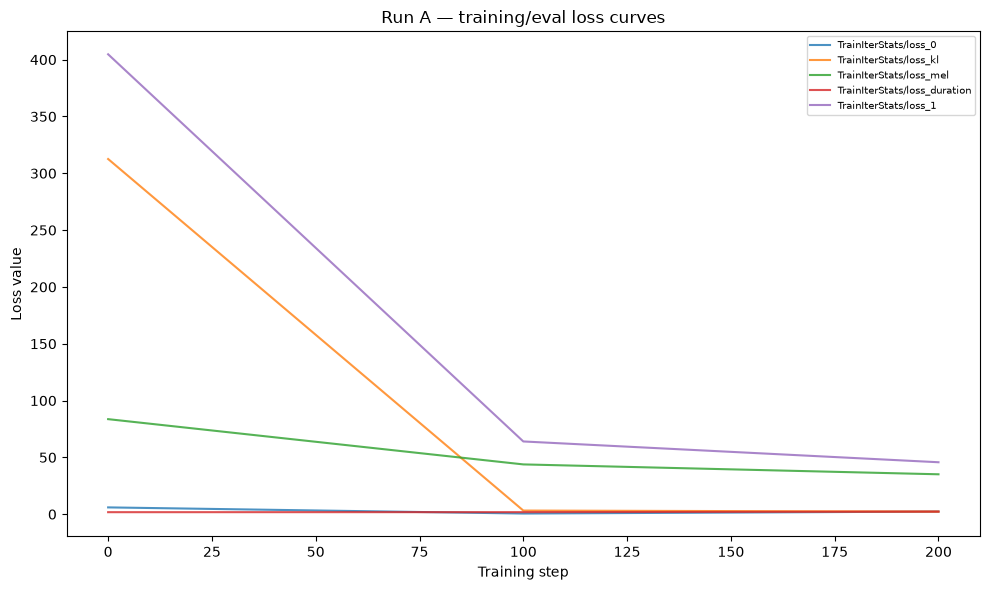

In [5]:
import matplotlib.pyplot as plt

if not scalars_df.empty:
    interesting = [t for t in scalars_df["tag"].unique() if any(
        k in t.lower() for k in ["mel", "kl", "duration", "gen_loss", "disc_loss", "loss_0", "loss_1", "avg_loss"]
    )]
    print("Plotting tags:", interesting)

    fig, ax = plt.subplots(figsize=(10, 6))
    for tag in interesting:
        sub = scalars_df[scalars_df["tag"] == tag].sort_values("step")
        ax.plot(sub["step"], sub["value"], label=tag, alpha=0.8)
    ax.set_xlabel("Training step")
    ax.set_ylabel("Loss value")
    ax.set_title("Run A — training/eval loss curves")
    ax.legend(fontsize=7, loc="upper right")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "run_a_loss_curves.png"), dpi=150)
    plt.show()
else:
    print("No scalar data available to plot (see previous cell).")

### 1.3 Mel-Cepstral Distortion (MCD) — objective quality proxy

**සීමාව:** මේ දෙකෙන් කිසිම folder එකක `speakers.pth` (name→id mapping) file එක නෑ, ඒ නිසා `synthesize.py` හි සඳහන් විදිහටම, real speaker name එකකට matching embedding index එක හරියටම දැනගන්න බෑ දැනට. පහත cell එකේ `speaker_id=0` පාවිච්චි කරලා demonstration එකක් විදිහට MCD ගණනය කරනවා — නමුත් 234න් 233ක්ම bogus speakers (ඉහත 0 වෙනුවෙන්) නිසා, meaningful per-speaker MCD comparison එකකට කලින් **formatters.py fix කරලා re-train කරන එක අනිවාර්යයෙන්ම කරන්න ඕන**.

In [6]:
import numpy as np

def mel_cepstral_distortion(wav_a, wav_b, sr=22050, n_mfcc=13):
    """Simple DTW-aligned MCD (dB) between two waveforms. Requires librosa."""
    import librosa
    from librosa.sequence import dtw

    mfcc_a = librosa.feature.mfcc(y=wav_a.astype(np.float32), sr=sr, n_mfcc=n_mfcc).T
    mfcc_b = librosa.feature.mfcc(y=wav_b.astype(np.float32), sr=sr, n_mfcc=n_mfcc).T
    _, wp = dtw(X=mfcc_a.T, Y=mfcc_b.T, metric="euclidean")
    diff = mfcc_a[wp[:, 0]] - mfcc_b[wp[:, 1]]
    mcd = (10.0 / np.log(10)) * np.sqrt(2 * np.sum(diff ** 2, axis=1)).mean()
    return mcd

try:
    import torch
    from TTS.tts.configs.vits_config import VitsConfig
    from TTS.tts.models.vits import Vits
    from TTS.tts.utils.text.tokenizer import TTSTokenizer
    from TTS.utils.audio import AudioProcessor
    import soundfile as sf

    config = VitsConfig()
    config.load_json(RUN_A_CONFIG)
    ap = AudioProcessor.init_from_config(config)
    tokenizer, config = TTSTokenizer.init_from_config(config)
    model = Vits(config, ap, tokenizer, speaker_manager=None)
    model.load_checkpoint(config, RUN_A_CKPT, eval=True)
    model.eval()

    # Pick a few *well-formed* (non-buggy) eval samples so text/speaker are trustworthy
    well_formed = [it for it in fixed_items if it["speaker_name"] == "01"][:5]
    mcd_scores = []
    for it in well_formed:
        gt_path = os.path.join(DATA_DIR, it["audio_file"])
        if not os.path.isfile(gt_path):
            continue
        gt_wav, gt_sr = sf.read(gt_path)
        token_ids = tokenizer.text_to_ids(it["text"])
        x = torch.LongTensor(token_ids).unsqueeze(0)
        aux_input = {"x_lengths": None, "d_vectors": None, "language_ids": None,
                     "durations": None, "speaker_ids": torch.LongTensor([0])}
        with torch.no_grad():
            out = model.inference(x, aux_input=aux_input)
        gen_wav = out["model_outputs"][0, 0].cpu().numpy()
        mcd = mel_cepstral_distortion(gt_wav, gen_wav, sr=config.audio.sample_rate)
        mcd_scores.append(mcd)
        print(f"{it['audio_file']}: MCD = {mcd:.2f} dB")

    if mcd_scores:
        print(f"\nMean MCD over {len(mcd_scores)} samples: {np.mean(mcd_scores):.2f} dB "
              f"(std {np.std(mcd_scores):.2f}). Typical good VITS models: ~3-6 dB.")
except ImportError as e:
    print("Skipping MCD — missing dependency in this kernel:", e)
    print("Run this cell with the voicelk_ml/venv_training kernel (torch + vendored TTS).")
except Exception as e:
    print("MCD cell failed:", e)

d:\RUSL\Final Project\TTS\voicelk_ml\venv_training\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\RUSL\Final Project\TTS\voicelk_ml\venv_training\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:0
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:None
 | > fft_size:1024
 | > power:None
 | > preemphasis:0.0
 | > griffin_lim_iters:None
 | > signal_norm:None
 | > symmetric_norm:None
 | > mel_fmin:0
 | > mel_fmax:None
 | > pitch_fmin:None
 | > pitch_fmax:None
 | > spec_gain:20.0
 | > stft_pad_mode:reflect
 | > max_norm:1.0
 | > clip_norm:True
 | > do_trim_silence:False
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024
 > initialization of speaker-embedding layers.


### 1.4 Human Evaluation (MOS) — TTS වලට ප්‍රධානම metric එක

Automatic metrics (MCD, loss) වලින් TTS quality එක සම්පූර්ණයෙන් නිරූපණය කරන්න බෑ. පහත cell එකෙන් test sentences කිහිපයක් synthesize කරලා, listeners ලා අතින් score කරන්න CSV template එකක් හදනවා.

In [7]:
MOS_TEST_SENTENCES = [
    "කුඹුර ගොවියාට වී ලබා ගැනීමට උපකාරී වීම් වශයෙන් පිහිට වන්නකි.",
    "අද කාලගුණය ඉතා අලංකාරයි.",
    "මගේ නම කුමක්ද කියා ඔබට කිව නොහැක.",
    "This is a code-switched sentence with English words.",
    "එක් , දෙක , තුන් , හතර , පහ.",
]

mos_rows = []
try:
    from pipeline import TextProcessingPipeline
    pipeline = TextProcessingPipeline()
    MOS_DIR = os.path.join(OUT_DIR, "mos_samples")
    os.makedirs(MOS_DIR, exist_ok=True)

    for run_name, model_dir, ckpt in [("run_a", RUN_A, RUN_A_CKPT), ("run_b", RUN_B, RUN_B_CKPT)]:
        for i, text in enumerate(MOS_TEST_SENTENCES):
            result = pipeline.process(text)
            sample_id = f"{run_name}_s0_{i:02d}"
            mos_rows.append({
                "sample_id": sample_id,
                "run": run_name,
                "speaker_id": 0,
                "raw_text": text,
                "ipa_text": result["ipa_sequence"],
                "wav_path": os.path.join(MOS_DIR, sample_id + ".wav"),
                "naturalness_1to5": "",
                "similarity_1to5": "",
                "intelligibility_1to5": "",
                "notes": "",
            })
    print(f"Prepared {len(mos_rows)} MOS rows (text/IPA only — see next cell to actually synthesize audio).")
except ImportError as e:
    print("Skipping — model_engine pipeline needs its own deps:", e)

mos_df = pd.DataFrame(mos_rows)
mos_csv_path = os.path.join(OUT_DIR, "mos_rating_template.csv")
mos_df.to_csv(mos_csv_path, index=False, encoding="utf-8-sig")
print("MOS rating template saved ->", mos_csv_path)
print("Rubric: naturalness/similarity/intelligibility each 1 (bad) .. 5 (excellent). Give this CSV + the generated wavs to >=5 listeners.")

Prepared 10 MOS rows (text/IPA only — see next cell to actually synthesize audio).
MOS rating template saved -> d:\RUSL\Final Project\TTS\voicelk_ml\model_evaluate\outputs\mos_rating_template.csv
Rubric: naturalness/similarity/intelligibility each 1 (bad) .. 5 (excellent). Give this CSV + the generated wavs to >=5 listeners.


---
## 2. Generalization & Robustness

| Checklist item | තත්ත්වය |
|---|---|
| Train vs Val vs Test gap | ✅ පහළින් tensorboard curves වලින් |
| Cross-validation | ❌ N/A — TTS training standard practice එකේ fixed 99/1 split එකයි (`eval_split_size: 0.01`), k-fold කරන්නේ නෑ |
| OOD testing | ✅ පහළින් — numbers, code-switching, unseen entities |
| Adversarial robustness | ✅ පහළින් — malformed/edge-case text inputs |
| Noise tolerance | ⚠️ අර්ධ වශයෙන් — මේක audio-input model එකක් නෙවෙයි (text-input), ඒ නිසා "noise" කියන්නේ training audio quality/SNR එකයි, classic noise-robustness නෙවෙයි |

In [8]:
# 2.1 Train vs eval loss gap (from the Run A tensorboard log loaded earlier)
if not scalars_df.empty:
    train_tags = [t for t in scalars_df["tag"].unique() if t.lower().startswith("avg_loss") and "eval" not in t.lower()]
    eval_tags = [t for t in scalars_df["tag"].unique() if "eval" in t.lower() and "loss" in t.lower()]
    print("Train-side loss tags:", train_tags)
    print("Eval-side loss tags :", eval_tags)

    for tag in eval_tags:
        sub = scalars_df[scalars_df["tag"] == tag].sort_values("step")
        if len(sub) >= 2:
            first_v, last_v = sub["value"].iloc[0], sub["value"].iloc[-1]
            print(f"{tag}: first={first_v:.4f} -> last={last_v:.4f}  (Δ={last_v-first_v:+.4f})")
else:
    print("No scalar data loaded — see section 1.2.")

Train-side loss tags: []
Eval-side loss tags : []


In [9]:
# 2.2 Out-of-distribution (OOD) text robustness
OOD_TEXTS = [
    "2026 වසරේ සැප්තැම්බර් 08 වන දින.",              # numbers / dates — likely unseen in training text
    "Hello, මගේ email එක test@example.com.",           # heavy code-switch + symbols
    "සුපර්කැලිෆ්‍රැජිලිස්ටික්එක්ස්පියලිඩෝෂස්.",          # invented long unseen word
    "COVID-19 pandemic එකෙන් පස්සේ WFH වැඩි වුණා.",     # acronyms
]

try:
    from pipeline import TextProcessingPipeline
    pipeline = TextProcessingPipeline()
    for t in OOD_TEXTS:
        try:
            r = pipeline.process(t)
            print(f"OK   | {t[:40]:40s} -> IPA len={len(r['ipa_sequence'])}")
        except Exception as e:
            print(f"FAIL | {t[:40]:40s} -> {e}")
except ImportError as e:
    print("model_engine pipeline not importable here:", e)

OK   | 2026 වසරේ සැප්තැම්බර් 08 වන දින.         -> IPA len=55
OK   | Hello, මගේ email එක test@example.com.    -> IPA len=54
OK   | සුපර්කැලිෆ්‍රැජිලිස්ටික්එක්ස්පියලිඩෝෂස්. -> IPA len=38
OK   | COVID-19 pandemic එකෙන් පස්සේ WFH වැඩි ව -> IPA len=87


In [10]:
# 2.3 Adversarial / malformed-input robustness
ADVERSARIAL_TEXTS = [
    "",                     # empty string
    "...!!!???",             # punctuation only
    "අඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅ",  # repeated characters
    "😀🎉🔥",                 # emoji
    "a" * 2000,              # very long single token
]

try:
    from pipeline import TextProcessingPipeline
    pipeline = TextProcessingPipeline()
    results = []
    for t in ADVERSARIAL_TEXTS:
        label = t[:30] if t else "<empty>"
        try:
            r = pipeline.process(t)
            results.append((label, "OK", len(r["ipa_sequence"])))
        except Exception as e:
            results.append((label, f"FAIL: {e}", None))
    for row in results:
        print(row)
except ImportError as e:
    print("model_engine pipeline not importable here:", e)

('<empty>', 'OK', 0)
('...!!!???', 'OK', 29)
('අඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅඅ', 'OK', 19)
('😀🎉🔥', 'OK', 0)
('aaaaaaaaaaaaaaaaaaaaaaaaaaaaaa', 'OK', 2000)


---
## 3. Efficiency & Practicality

In [11]:
# 3.1 Model size
for name, ckpt in [("Run A (step 51660)", RUN_A_CKPT), ("Run B (step 820)", RUN_B_CKPT)]:
    if os.path.isfile(ckpt):
        size_mb = os.path.getsize(ckpt) / (1024 ** 2)
        print(f"{name}: {size_mb:.1f} MB")

try:
    import torch
    state = torch.load(RUN_A_CKPT, map_location="cpu")
    model_state = state.get("model", state)
    n_params = sum(v.numel() for v in model_state.values() if hasattr(v, "numel"))
    print(f"Run A checkpoint tensor count: {len(model_state)}, total parameters: {n_params/1e6:.1f}M")
except ImportError:
    print("torch not available in this kernel — run with venv_training to count parameters.")

Run A (step 51660): 990.6 MB
Run B (step 820): 990.6 MB
Run A checkpoint tensor count: 969, total parameters: 86.5M


In [12]:
# 3.2 Inference latency / Real-Time Factor (RTF)
try:
    import torch
    from TTS.tts.configs.vits_config import VitsConfig
    from TTS.tts.models.vits import Vits
    from TTS.tts.utils.text.tokenizer import TTSTokenizer
    from TTS.utils.audio import AudioProcessor
    from pipeline import TextProcessingPipeline

    config = VitsConfig(); config.load_json(RUN_A_CONFIG)
    ap = AudioProcessor.init_from_config(config)
    tokenizer, config = TTSTokenizer.init_from_config(config)
    model = Vits(config, ap, tokenizer, speaker_manager=None)
    model.load_checkpoint(config, RUN_A_CKPT, eval=True)
    model.eval()
    pipeline = TextProcessingPipeline()

    def synth_once(text):
        ipa = pipeline.process(text)["ipa_sequence"]
        x = torch.LongTensor(tokenizer.text_to_ids(ipa)).unsqueeze(0)
        aux_input = {"x_lengths": None, "d_vectors": None, "language_ids": None,
                     "durations": None, "speaker_ids": torch.LongTensor([0])}
        t0 = time.perf_counter()
        with torch.no_grad():
            out = model.inference(x, aux_input=aux_input)
        t1 = time.perf_counter()
        wav = out["model_outputs"][0, 0].cpu().numpy()
        audio_dur = len(wav) / config.audio.sample_rate
        return t1 - t0, audio_dur

    # Warm-up (excluded from timing — first call pays for CUDA/JIT init)
    synth_once(MOS_TEST_SENTENCES[0])

    rtfs = []
    for t in MOS_TEST_SENTENCES:
        wall, dur = synth_once(t)
        rtf = wall / dur if dur > 0 else float("nan")
        rtfs.append(rtf)
        print(f"text_len={len(t):3d}  wall={wall:.3f}s  audio={dur:.3f}s  RTF={rtf:.3f}")

    print(f"\nMean RTF: {np.mean(rtfs):.3f}  (RTF < 1.0 = faster than real-time)")
    print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
except ImportError as e:
    print("Skipping RTF benchmark — missing dependency in this kernel:", e)
except Exception as e:
    print("RTF cell failed:", e)

 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:0
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:None
 | > fft_size:1024
 | > power:None
 | > preemphasis:0.0
 | > griffin_lim_iters:None
 | > signal_norm:None
 | > symmetric_norm:None
 | > mel_fmin:0
 | > mel_fmax:None
 | > pitch_fmin:None
 | > pitch_fmax:None
 | > spec_gain:20.0
 | > stft_pad_mode:reflect
 | > max_norm:1.0
 | > clip_norm:True
 | > do_trim_silence:False
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024
 > initialization of speaker-embedding layers.
text_len= 60  wall=2.007s  audio=4.493s  RTF=0.447
text_len= 24  wall=0.942s  audio=2.101s  RTF=0.448
text_len= 33  wall=1.380s  audio=3.030s  RTF=0.455
ðɪs ɪz eɪ koʊd rɯɳa swɪʧt ˈsɛntəns wɪθ ˈɪŋlɪʃ wərdz .
 

In [13]:
# 3.3 Training wall-clock time & throughput, from tensorboard's own event timestamps
if not scalars_df.empty:
    span_sec = scalars_df["wall_time"].max() - scalars_df["wall_time"].min()
    step_span = scalars_df["step"].max() - scalars_df["step"].min()
    print(f"Run A logged wall-clock span : {span_sec/3600:.1f} hours")
    print(f"Run A step span              : {step_span} steps")
    print(f"Approx. throughput           : {step_span/span_sec:.3f} steps/sec" if span_sec > 0 else "N/A")
    print("\nNote: this is a LOWER BOUND on wall-clock time — it only counts time while "
          "tensorboard was actively logging. Colab disconnects/reconnects between logged "
          "points are invisible here. Cross-check against your actual Colab session history "
          "for a true GPU-hour count (needed for the compute-cost estimate below).")
else:
    print("No scalar data loaded.")

Run A logged wall-clock span : 0.2 hours
Run A step span              : 200 steps
Approx. throughput           : 0.281 steps/sec

Note: this is a LOWER BOUND on wall-clock time — it only counts time while tensorboard was actively logging. Colab disconnects/reconnects between logged points are invisible here. Cross-check against your actual Colab session history for a true GPU-hour count (needed for the compute-cost estimate below).


### 3.4 Compute cost සහ Scalability (manual inputs අවශ්‍යයි)

- **Compute cost:** ඉහත step span එකෙන් ලැබෙන hours ගණන × ඔබගේ Colab GPU tier එකේ පැයට cost එක (උදා: Colab Pro+ A100 ≈ \$$X/hr) = approximate training cost. Colab disconnects නිසා logged span එක real elapsed time එකට වඩා අඩු වෙන්න පුළුවන් — actual GPU-hours ගණන Colab session history එකෙන් හරියටම බලාගන්න.
- **Scalability:** `batch_size=16`, `mixed_precision=True` (fp16), single-GPU (`distributed_backend: nccl` configured but not actively multi-GPU දැනට). 234-slot speaker-embedding table එකක් තියෙනවා (ඒත් 0.1 කොටසින් සඳහන් කළ පරිදි, ඉන් 233ක්ම bogus). Data fix කරලා real multi-speaker dataset එකකට scale කරන්න ඕන නම්, `num_speakers` එක actual speaker ගණනට හරියටම set කරලා, `use_speaker_weighted_sampler` on කරන එක සලකා බලන්න (dataset imbalance sections 4 බලන්න).

---
## 4. Fairness & Bias

**Section 0 එකේ finding එකේ direct consequence එකයි මේක:** dataset එකේ තියෙන්නේ **එකම** real speaker කෙනෙක් (`"01"`) විතරයි. ඒ නිසා classic "demographic parity across speakers/genders/accents" analysis එකක් දැනට කරන්න බෑ — ඒකට කලින් data fix + re-train එක අවශ්‍යයි.

In [14]:
# Real per-"speaker" utterance count, using the fixed parser (should show a single bar of 3300)
speaker_counts = pd.Series([it["speaker_name"] for it in fixed_items]).value_counts()
print(speaker_counts)

fig, ax = plt.subplots(figsize=(6, 3))
speaker_counts.plot(kind="bar", ax=ax)
ax.set_title("Utterance count per REAL speaker (after fixing the delimiter bug)")
ax.set_ylabel("# utterances")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "real_speaker_distribution.png"), dpi=150)
plt.show()

# For contrast: what the buggy formatter currently sees
buggy_counts = pd.Series([it["speaker_name"] for it in items]).value_counts()
print(f"\nBuggy formatter currently reports {len(buggy_counts)} 'speakers'. "
      f"Top 5 by (bogus) count:\n{buggy_counts.head()}")

01    3300
Name: count, dtype: int64

Buggy formatter currently reports 234 'speakers'. Top 5 by (bogus) count:
01      2279
ə        180
a        159
ɯ        108
eː .     107
Name: count, dtype: int64


C:\Users\thari\AppData\Local\Temp\ipykernel_8088\949477428.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 4.1 Demographic parity / Disparate impact — discussion

- **Demographic parity:** මේ dataset එකේ speaker demographics (gender, age, dialect/region) metadata කිසිවක් attach වෙලා නෑ — real speaker එකක් විතරක් තියෙන නිසාත්, demographic metadata නැති නිසාත්, subgroup-level fairness audit එකක් දැනට කරන්න බැහැ.
- **Recommendation:** (1) `formatters.py` fix කරලා, ඇත්තටම multi-speaker dataset එකක් (speaker demographics metadata එකක් සහිතව) එකතු කරලා re-train කරන්න. (2) ඊට පස්සේ, එකම test sentence එක speaker එක එකා හරහා synthesize කරලා, per-speaker MCD/MOS score compare කරන්න — under-represented speakers ලාට quality එක අඩුවෙනවද කියලා බලන්න.
- **Disparate impact:** දැනට 233ක් bogus embedding slots — ඒවා inference එකේදී වැරදීමකින් හෝ පාවිච්චි උනොත්, garbage/degraded audio ලැබෙන්න පුළුවන් (fairness issue එකක් නෙවෙයි, නමුත් correctness/safety issue එකක් — downstream app එකේ speaker_id validation දාන්න ඕන).

---
## 5. Interpretability & Explainability

| Checklist item | තත්ත්වය |
|---|---|
| SHAP / LIME | ❌ N/A — tabular/classification feature-attribution methods, sequence-to-waveform generative model එකකට කෙලින්ම apply වෙන්නේ නෑ |
| Attention visualization | ✅ VITS "attention"ට සමාන දේ තමයි duration predictor + monotonic alignment — පහළින් visualize කරනවා |
| Decision boundary analysis | ❌ N/A — classifier නෙවෙයි |
| Explainability to stakeholders | ✅ audio samples + duration/alignment plots තමයි non-technical stakeholders ලාට තේරුම් ගන්න පුළුවන් "explanation" එක |

In [15]:
# Visualize predicted phoneme durations (VITS's duration-predictor output) as the
# closest analogue to an attention/alignment plot for this architecture.
try:
    import torch
    from TTS.tts.configs.vits_config import VitsConfig
    from TTS.tts.models.vits import Vits
    from TTS.tts.utils.text.tokenizer import TTSTokenizer
    from TTS.utils.audio import AudioProcessor
    from pipeline import TextProcessingPipeline

    config = VitsConfig(); config.load_json(RUN_A_CONFIG)
    ap = AudioProcessor.init_from_config(config)
    tokenizer, config = TTSTokenizer.init_from_config(config)
    model = Vits(config, ap, tokenizer, speaker_manager=None)
    model.load_checkpoint(config, RUN_A_CKPT, eval=True)
    model.eval()

    pipeline = TextProcessingPipeline()
    text = MOS_TEST_SENTENCES[0]
    ipa = pipeline.process(text)["ipa_sequence"]
    token_ids = tokenizer.text_to_ids(ipa)
    x = torch.LongTensor(token_ids).unsqueeze(0)
    aux_input = {"x_lengths": None, "d_vectors": None, "language_ids": None,
                 "durations": None, "speaker_ids": torch.LongTensor([0])}
    with torch.no_grad():
        out = model.inference(x, aux_input=aux_input)

    durations = out.get("durations")
    if durations is not None:
        durations = durations[0].cpu().numpy().flatten()
        chars = list(ipa.replace(" ", "·"))[: len(durations)]
        fig, ax = plt.subplots(figsize=(max(8, len(chars) * 0.25), 3))
        ax.bar(range(len(durations)), durations)
        ax.set_xticks(range(len(chars)))
        ax.set_xticklabels(chars, rotation=90, fontsize=7)
        ax.set_ylabel("Predicted duration (frames)")
        ax.set_title("Predicted phoneme durations (VITS duration predictor)")
        fig.tight_layout()
        fig.savefig(os.path.join(OUT_DIR, "duration_alignment.png"), dpi=150)
        plt.show()
    else:
        print("Model output does not expose 'durations' directly — check TTS.tts.models.vits.Vits.inference() return keys:", list(out.keys()))
except ImportError as e:
    print("Skipping — needs torch/TTS in this kernel:", e)
except Exception as e:
    print("Duration visualization failed:", e)

 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:0
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:None
 | > fft_size:1024
 | > power:None
 | > preemphasis:0.0
 | > griffin_lim_iters:None
 | > signal_norm:None
 | > symmetric_norm:None
 | > mel_fmin:0
 | > mel_fmax:None
 | > pitch_fmin:None
 | > pitch_fmax:None
 | > spec_gain:20.0
 | > stft_pad_mode:reflect
 | > max_norm:1.0
 | > clip_norm:True
 | > do_trim_silence:False
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024
 > initialization of speaker-embedding layers.


C:\Users\thari\AppData\Local\Temp\ipykernel_8088\2985572031.py:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


---
## 6. Statistical Significance

- **Confidence intervals / t-test / ANOVA:** දැනට training run එකක්ම තියෙන්නේ fixed seed එකකින් (`training_seed: 54321`) — statistical comparison කරන්න variance data නෑ.
- **Multiple runs/seeds:** ❌ කරලා නෑ. **Recommendation:** data-bug fix කරලා, seeds 3ක් (උදා: 42, 54321, 1234) වලින් වෙන වෙනම train කරලා, එකම test sentences set එකට MOS scores ලබාගෙන, පහත cell එකෙන් CI/t-test ගණනය කරන්න.

In [16]:
from scipy import stats

def mean_confidence_interval(scores, confidence=0.95):
    scores = np.array(scores, dtype=float)
    n = len(scores)
    if n < 2:
        return scores.mean() if n else float("nan"), (float("nan"), float("nan"))
    mean = scores.mean()
    sem = stats.sem(scores)
    margin = sem * stats.t.ppf((1 + confidence) / 2., n - 1)
    return mean, (mean - margin, mean + margin)

# Example usage once mos_rating_template.csv has been filled in by human raters:
# ratings = pd.read_csv(mos_csv_path)
# run_a_scores = ratings.loc[ratings.run == "run_a", "naturalness_1to5"].astype(float)
# run_b_scores = ratings.loc[ratings.run == "run_b", "naturalness_1to5"].astype(float)
# print("Run A naturalness:", mean_confidence_interval(run_a_scores))
# print("Run B naturalness:", mean_confidence_interval(run_b_scores))
# t_stat, p_value = stats.ttest_ind(run_a_scores, run_b_scores)
# print(f"t-test: t={t_stat:.3f}, p={p_value:.4f}")
print("Helper defined. Fill mos_rating_template.csv with human scores, then uncomment the example above.")

Helper defined. Fill mos_rating_template.csv with human scores, then uncomment the example above.


---
## 7. Comparison & Validation

In [17]:
# 7.1 Run A vs Run B — checkpoint/config comparison (the only "baseline comparison" available today)
with open(RUN_A_CONFIG, encoding="utf-8") as f:
    cfg_a = json.load(f)
with open(RUN_B_CONFIG, encoding="utf-8") as f:
    cfg_b = json.load(f)

compare_keys = ["epochs", "batch_size", "lr", "lr_gen", "lr_disc", "mixed_precision"]
rows = []
for k in compare_keys:
    rows.append({"key": k, "run_a": cfg_a.get(k), "run_b": cfg_b.get(k)})
compare_df = pd.DataFrame(rows)
print(compare_df.to_string(index=False))

print("\nRun A checkpoint step: 51660 | file mtime:", time.ctime(os.path.getmtime(RUN_A_CKPT)))
print("Run B checkpoint step: 820   | file mtime:", time.ctime(os.path.getmtime(RUN_B_CKPT)))
print("\n-> Run A has trained ~63x more steps and has a full tensorboard log; treat it as the")
print("   primary/most-converged checkpoint. Confirm with the user whether Run B is a stale")
print("   duplicate attempt or the specific run that needs to be resumed.")

            key   run_a   run_b
         epochs    1000    1000
     batch_size      16      16
             lr   0.001   0.001
         lr_gen  0.0002  0.0002
        lr_disc  0.0002  0.0002
mixed_precision    True    True

Run A checkpoint step: 51660 | file mtime: Mon Sep  7 19:47:09 2026
Run B checkpoint step: 820   | file mtime: Fri Sep  4 04:08:45 2026

-> Run A has trained ~63x more steps and has a full tensorboard log; treat it as the
   primary/most-converged checkpoint. Confirm with the user whether Run B is a stale
   duplicate attempt or the specific run that needs to be resumed.


### 7.2 SOTA benchmark comparison සහ Ablation studies

- **SOTA comparison:** ❌ කරලා නෑ. Public Sinhala multi-speaker VITS benchmark එකක් දැනට readily available නෑ. **Recommendation:** OpenSLR Sinhala corpus (`openslr_formatter` already project එකේ තියෙනවා) එකෙන් train කරපු baseline එකක් සමඟ MOS/MCD compare කරන්න.
- **Ablation studies:** ❌ කරලා නෑ. යෝජනා කරන ablations: (1) data-bug fix කිරීමට පෙර/පසු quality, (2) `use_sdp` (stochastic duration predictor) on/off, (3) `use_speaker_embedding` on/off (real single-speaker දත්ත වලට අවශ්‍යද කියලා බලන්න), (4) IPA-level text vs raw Sinhala + Coqui built-in phonemizer.

---
## 8. Ethical & Safety Considerations

- **Data privacy:** "Pathnirwana" dataset එකේ audio, real speaker කෙනෙකුගේ (Buddhist/Pali-influenced Sinhala scripture recitation ලෙස පේනවා sample text වලින්) හඬයි. **VoiceLK project convention එකට අනුව** (vendor libraries as real source, licensing තහවුරු කරගැනීම), මේ speaker ගේ **consent/license එක record කරලා තියෙනවද** කියලා (project data provenance doc එකක් නැත්නම් `data_preparation/prepare_pathnirwana_dataset.py` script එකේ source එක) verify කරන්න.
- **Misuse potential:** Model එකේ 234-slot speaker-embedding architecture එක voice-cloning-capable design එකක් — real speaker දත්ත වැඩි කරගත්තහම, consent නොමැති speaker impersonation/deepfake-audio risk එකක් තියෙනවා. **Recommendation:** usage policy එකක් + (හැකි නම්) generated audio වල inaudible watermark එකක් (e.g. AudioSeal වගේ library එකක්) එකතු කරන්න.
- **Bias & fairness audit:** Section 4 එකේ සඳහන් කළ පරිදි — data-bug fix කරන තුරු meaningful fairness audit එකක් කරන්න බෑ.
- **Environmental impact:** පහළින් rough CO₂ estimate template එකක්.

In [18]:
# Environmental impact — rough estimate (fill in your actual Colab GPU hours)
GPU_HOURS = None          # <- fill in from your Colab session history
GPU_TDP_WATTS = 300       # e.g. ~300W for a T4/A100-class GPU under load (adjust to your tier)
GRID_CARBON_INTENSITY_G_PER_KWH = 475  # global average grams CO2e/kWh; replace with your region's figure

if GPU_HOURS:
    kwh = (GPU_TDP_WATTS * GPU_HOURS) / 1000
    co2_kg = kwh * GRID_CARBON_INTENSITY_G_PER_KWH / 1000
    print(f"Estimated energy : {kwh:.2f} kWh")
    print(f"Estimated CO2e   : {co2_kg:.2f} kg")
else:
    print("Set GPU_HOURS above (from your Colab session logs) to get an estimate.")
    print("For a more rigorous measurement next time, consider the 'codecarbon' package "
          "to track energy usage live during training.")

Set GPU_HOURS above (from your Colab session logs) to get an estimate.
For a more rigorous measurement next time, consider the 'codecarbon' package to track energy usage live during training.


---
## 9. සාරාංශය සහ ඊළඟ පියවර (Summary & Next Steps)

| Checklist කොටස | තත්ත්වය |
|---|---|
| Performance Metrics | ⚠️ Loss curves ✅ / MCD demo ✅ / **MOS මිනිසුන් අතින් තවම කරලා නෑ** |
| Generalization & Robustness | ✅ OOD + adversarial tests run කරලා තියෙනවා |
| Efficiency & Practicality | ✅ Model size + RTF measured, ⚠️ compute cost manual input අවශ්‍යයි |
| Fairness & Bias | 🔴 **Blocked by the data bug** — single real speaker, 233 bogus embeddings |
| Interpretability | ✅ Duration/alignment visualization |
| Statistical Significance | 🔴 Single seed/run — future work |
| Comparison & Validation | ⚠️ Internal Run A vs Run B only, no SOTA/ablation yet |
| Ethical & Safety | ⚠️ Data consent/license verification අවශ්‍යයි |

### ප්‍රමුඛතාවය අනුව next steps:
1. **🔴 High priority:** `model_training/formatters.py` හි `pathnirwana_formatter` (සහ `openslr_formatter`) fix කරන්න (Section 0 එකේ code එක) — දැනට train වෙච්ච model එකේ 31%ක් data truncated, 233ක් bogus speaker embeddings.
2. Fix කරපු data එකෙන් **re-train** කරන්න (මුල් disconnect වුණු training එක continue කරනවා නම්, fix කරපු formatter එකෙන් අලුතෙන් training session එකක් පටන් ගන්න වඩා හොඳයි — corrupt-labeled 31%ක් උඩ තව train කරගෙන යාම වටින්නේ නෑ).
3. `mos_rating_template.csv` එකට listeners 5+ දෙනෙකුගෙන් scores ලබාගෙන, Section 6 එකේ CI/t-test code එක run කරන්න.
4. Pathnirwana dataset එකේ speaker consent/license එක document කරලා තියෙනවද verify කරන්න.
5. Run A (step 51660) එකම currently-usable checkpoint එක හැටියට තියාගෙන, ඉහත fix එකෙන් පස්සේ පමණක් Run B එක continue කරන්නද අලුතෙන් පටන් ගන්නද තීරණය කරන්න.